In [1]:
import os
from dotenv import load_dotenv

# Load variables from the .env file into the environment
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv("GROQQ_API_KEY")

In [2]:
import os
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import START,END,MessagesState,StateGraph
from operator import add
from typing_extensions import TypedDict
from typing import List, Optional, Annotated
from langgraph.constants import Send



In [3]:
# os.environ['GROQ_API_KEY'] = os.getenv("GROQQ_API_KEY")
# llm = ChatGroq(model="llama3-8b-8192", temperature=0)

# Parallel Execution using Multi-State

In [4]:
# import operator

# class State(TypedDict):
#     table : Annotated[list, operator.add]
#     number : int

# class TableState(TypedDict):
#     number : int
#     value : int


# def get_value(state:State):
#     number=state['number']
#     return [Send("create_table", {"value":val, "number":number}) for val in range(1,11)]

    
# def create_table(state:TableState):
#     number=state['number']
#     value=state['value']
#     mul_val=number*value
#     return {'table':[mul_val]}

In [5]:
# workflow=StateGraph(State)
# workflow.add_node("create_table",create_table)
# workflow.add_conditional_edges(START,get_value,"create_table")
# app=workflow.compile()

In [6]:
# app.get_graph().to_json()

In [7]:
# for msg in app.stream({'number':5},stream_mode="updates"):
#     print(msg)
#     print("_"*5)

In [8]:
# app.invoke({'number':5})

# Parallel Execution using just Single State

In [9]:
import operator

class State(TypedDict):
    table : Annotated[list, operator.add]
    number : int
    value : int

# class TableState(TypedDict):
#     number : int
#     value : int


def get_value(state:State):
    number=state['number']
    return [Send("create_table", {"value":val,"number":number}) for val in range(1,11)]

    
def create_table(state:State):

    value=state['value']
    number=state['number']
    mul_val=number*value
    return {'table':[mul_val]}

graph=StateGraph(State)
graph.add_node("create_table",create_table)
graph.add_conditional_edges(START,get_value,["create_table"])
appz=graph.compile()

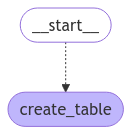

In [10]:
from IPython.display import Image, display

try:
    display(Image(appz.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [11]:

for msg in appz.stream({'number':5},stream_mode="values"):
    print(msg)
    print("_"*5)

{'table': [], 'number': 5}
_____
{'table': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50], 'number': 5}
_____


In [12]:
appz.invoke({'number':5})

{'table': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50], 'number': 5}

In [13]:
appz.get_graph().to_json()

{'nodes': [{'id': '__start__', 'type': 'schema', 'data': '__start__'},
  {'id': 'create_table',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'utils', 'runnable', 'RunnableCallable'],
    'name': 'create_table'}}],
 'edges': [{'source': '__start__',
   'target': 'create_table',
   'conditional': True}]}

# Testing how to handle Contitional Edge with List

In [14]:
# # approved
# from pprint import pprint


# def group_by_source_and_function(dicts):
#     grouped = {}
#     for item in dicts:
#         key = (item['source'], item['function'])
#         if key not in grouped:
#             grouped[key] = []
#         grouped[key].append(item)
#     return grouped

# # Example usage:
# input_dicts = [
#     {'source': 'classifier', 'target': 'retrieve', 'data': 'Amazon', 'conditional': True, 'function': 'router'},
#     {'source': 'classifier', 'target': 'greeting', 'data': 'welcome', 'conditional': True, 'function': 'router'},
#     {'source': 'classifier', 'target': 'greeting', 'data': 'other', 'conditional': True, 'function': 'router'},
#     {'source': 'grader', 'target': 'greeting', 'data': 'other', 'conditional': True, 'function': 'gen'},
#     {'source': 'grader', 'target': 'greeting', 'data': 'other', 'conditional': True, 'function': 'gen'},
#     {'source': 'doc', 'target': 'greeting', 'data': 'other', 'conditional': True, 'function': 'ans'},
#     {'source': 'doc', 'target': 'greeting', 'data': 'other', 'conditional': True, 'function': 'ans'},
#     {'source': 'answer_question', 'target': 'ask_question', 'conditional': True, 'function': 'route_messages'},
#     {'source': 'answer_question','target': 'save_interview','conditional': True, 'function': 'route_messages'}
# ]

# grouped_output = group_by_source_and_function(input_dicts)
# pprint(grouped_output, sort_dicts=False)


In [15]:
# all_conditional_edges=grouped_output
# for conditional_edge in all_conditional_edges:
#     # print(conditional_edge)
#     print(all_conditional_edges[conditional_edge])
#     print("__"*10)

In [16]:
# if conditional_edges:
#     all_conditional_edges= group_by_source_and_function(conditional_edges)

#     for conditional_edge in all_conditional_edges:
#         if all_conditional_edges[conditional_edge][0]['condition_type'] == 'dict':
#             conditional_dict={}
#             edge_source, edge_function = conditional_edge
#             for edge in all_conditional_edges[conditional_edge]:
#                 conditional_dict[edge['data']]=edge['target']

#             function_ref = get_function_reference(edge_function)
#             workflow.add_conditional_edges(edge_source, function_ref, conditional_dict)
        
#         # here we have main args in conditional-edge-dict source, target, function
#         # we will apend target in list
#         if all_conditional_edges[conditional_edge][0]['condition_type'] == 'list':
#             conditional_list=[]
#             edge_source, edge_function = conditional_edge
#             for edge in all_conditional_edges[conditional_edge]:
#                 conditional_list.append(edge['target'])

#             function_ref = get_function_reference(edge_function)
#             workflow.add_conditional_edges(edge_source, function_ref, conditional_list)
        



# Creating Json for parallel-Exe 

In [22]:
inputz_json={'nodes': [{'id': '__start__', 'type': 'schema', 'data': '__start__'},
  {'id': 'create_table',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'utils', 'runnable', 'RunnableCallable'],
    'name': 'create_table'},
    'inputs':{'number':5},
    'output':{}}],

 'edges': [{'source': '__start__',
   'target': 'create_table',
   'conditional': True,
   'condition_type': 'list',
   'function':'get_value'}]}

In [ ]:
{'source': 'sourse-node',
   'target': 'target-node',
}

In [ ]:
from inspect import isframe
from langchain_core.prompts import ChatPromptTemplate
from typing import Dict, TypedDict, Optional
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph
from typing import Dict, Callable
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END, START
from typing import Annotated, List, Sequence
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
import json
import os

# _________________________________________________
node_list = []


# graph states

# class GraphState(TypedDict):
#     messages: Annotated[Sequence[BaseMessage], add_messages]
#     #Inputs:
#     youtube_url: str
#     input_text: str
#     content: str
#     audience: str
#     tone: str
#     length: str
#     website_url: str
#     prompt: str
#     context: str
#     #Outputs:
#     transcript: str
#     blog: str
#     summary : str
#     website_scraped_content: str
#     ai_response: str



# Helping Functions
def check_previous_node(node_id,node_list):
    target = node_id
    previous_element = ''
    if target in node_list:
        index = node_list.index(target)  # Get the index of the target element
        if index > 0:  # Check if there is a previous element
            previous_element = node_list[index - 1]
            print(f"The previous element of '{target}' is '{previous_element}'.")
        else:
            print(f"'{target}' has no previous element.")
    else:
        print(f"'{target}' is not in the list.")
    return previous_element

# def extract_nodes(input_json):
#   flow = []
#   edges = input_json['edges']
#   current_node = '__start__'
#   while current_node != '__end__':
#       flow.append(current_node)
#       # Find the next node in the flow:
#       next_edge = next(edge for edge in edges if edge['source'] == current_node)
#       current_node = next_edge['target']
#   flow.append('__end__')
#   return flow

# all nodes output registory
# all_node_outputs = {
#     'Ask_AI': 'ai_response',
#     'Website_Scraper':'website_scraped_content',
#     # 'Blog_Writer' : 'blog',
#     'Get_Youtube_Transcript': 'transcript',
#     'summarize': 'summary'
# }

# ________________________________________________


function_registry = {
    "create_table": create_table,
    "get_value": get_value,
}

# function ragistory
def get_function_reference(function_name: str) -> Callable:
    return function_registry.get(function_name, lambda: None)




# _______________________________________________________

#########################################################################################################################################


# graph builder
def group_by_source_and_function(dicts):
    grouped = {}
    for item in dicts:
        key = (item['source'], item['function'])
        if key not in grouped:
            grouped[key] = []
        grouped[key].append(item)
    return grouped



def build_graph_from_json(output_json: Dict,  mainstate = None, inputstate = None, outputstate = None) -> Callable:
    input_var_dict={}
    conditional_edges=[]

    # Step 1: Initialize the graph with config
    workflow = StateGraph(state_schema=mainstate, input=inputstate, output=outputstate)

    # Step 2: Add all nodes to the workflow based on the output JSON
    for node in output_json["nodes"]:
        node_id = node["id"]

        # Skip special start and end nodes in this step
        if node_id in ["__start__", "__end__"]:
            continue

        # Retrieve the function for this node
        function_name = node["data"].get("name")
        function_ref = get_function_reference(function_name)

        # Add the node with the associated function
        workflow.add_node(node_id, function_ref)

        # extract input variables from node-json
        input_var_dict.update(node["inputs"])



    # Step 3: Set the entry point if there's an edge from "__start__"
    for edge in output_json["edges"]:
        if not "conditional" in edge:
            if edge["source"] == "__start__":
                workflow.add_edge(edge["source"],edge["target"])
                # workflow.set_entry_point(edge["target"])
            
    # Step 4: Set the end point if there's an edge from "__end__"
    for edge in output_json["edges"]:
      if not "conditional" in edge:
        if edge["target"] == "__end__":
            workflow.add_edge(edge["source"],edge["target"])
            

    # Step 5: Add edges to the workflow
    for edge in output_json["edges"]:
        

        # Skip "__start__" and "__end__" here, as they have special handling
        # if source == "__start__" or target == "__end__":
        #     continue

        # Determine if the edge is conditional
        # conditional = edge.get("conditional", "False") == "True"
        if "conditional" in edge:
            # Retrieve the conditional edges and append to seprate conditional lists
            conditional_edges.append(edge)
        else:
            source = edge["source"]
            target = edge["target"]
            # Add a normal edge if it's not conditional
            workflow.add_edge(source, target)

    c_type=None
    if conditional_edges:
        c_type='conditional'
        all_conditional_edges= group_by_source_and_function(conditional_edges)

        for conditional_edge in all_conditional_edges:
            
            if all_conditional_edges[conditional_edge][0]['condition_type'] == 'dict':
                c_type='dict'
                conditional_dict={}
                edge_source, edge_function = conditional_edge
                for edge in all_conditional_edges[conditional_edge]:
                    conditional_dict[edge['data']]=edge['target']

                function_ref = get_function_reference(edge_function)
                workflow.add_conditional_edges(edge_source, function_ref, conditional_dict)
            
            # here we have main args in conditional-edge-dict source, target, function
            # we will apend target in list
            if all_conditional_edges[conditional_edge][0]['condition_type'] == 'list':
                c_type='list'
                conditional_list=[]
                edge_source, edge_function = conditional_edge
                for edge in all_conditional_edges[conditional_edge]:
                    conditional_list.append(edge['target'])

                function_ref = get_function_reference(edge_function)
                workflow.add_conditional_edges(edge_source, function_ref, conditional_list)

        return workflow,input_var_dict,c_type


    else:
      return workflow,input_var_dict,c_type


def graph_builder(input_json = None , mainstate = None, inputstate = None, outputstate = None):
  workflow,input_dict,c_type = build_graph_from_json(output_json = input_json, mainstate = mainstate, inputstate = inputstate, outputstate = outputstate)
  app = workflow.compile()
  # node_list = extract_nodes(input_json)
  # print(f"The Nodes are(In order):\n {node_list}")
  # return app,input_dict,node_list
  return app,input_dict,c_type

In [59]:
compile_app_1,input_dict,c_type=graph_builder(input_json=input_json, mainstate=State)

In [60]:
print(c_type)

list


In [63]:
input_dict

{'number': 5}

In [61]:
compile_app_1.invoke(input_dict)

{'table': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50], 'number': 5}

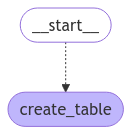

In [62]:
compile_app_1

In [ ]:
# this code is to store code befor major changes in WorkFlowRunner Project
# _________________________________________________________________________

# def build_graph_from_json(output_json: Dict,  mainstate = None, inputstate = None, outputstate = None) -> Callable:
    
#     input_var_dict={}
#     conditional_edges=[]

#     # Step 1: Initialize the graph with config
#     workflow = StateGraph(state_schema=mainstate, input=inputstate, output=outputstate)

#     # Step 2: Add all nodes to the workflow based on the output JSON
#     for node in output_json["nodes"]:
#         node_id = node["id"]

#         # Skip special start and end nodes in this step
#         if node_id in ["__start__", "__end__"]:
#             continue

#         # Retrieve the function for this node
#         function_name = node["data"].get("name")
#         function_ref = get_function_reference(function_name)

#         # Add the node with the associated function
#         workflow.add_node(node_id, function_ref)

#         # extract input variables from node-json
#         input_var_dict.update(node["inputs"])



#     # Step 3: Set the entry point if there's an edge from "__start__"
#     for edge in output_json["edges"]:
#         if not "conditional" in edge:
#             if edge["source"] == "__start__":
#                 workflow.add_edge(edge["source"],edge["target"])
#                 # workflow.set_entry_point(edge["target"])
            
#     # Step 4: Set the end point if there's an edge from "__end__"
#     for edge in output_json["edges"]:
#       if not "conditional" in edge:
#         if edge["target"] == "__end__":
#             workflow.add_edge(edge["source"],edge["target"])
            

#     # Step 5: Add edges to the workflow
#     for edge in output_json["edges"]:
        

#         # Skip "__start__" and "__end__" here, as they have special handling
#         # if source == "__start__" or target == "__end__":
#         #     continue

#         # Determine if the edge is conditional
#         # conditional = edge.get("conditional", "False") == "True"
#         if "conditional" in edge:
#             # Retrieve the conditional edges and append to seprate conditional lists
#             conditional_edges.append(edge)
#         else:
#             source = edge["source"]
#             target = edge["target"]
#             # Add a normal edge if it's not conditional
#             workflow.add_edge(source, target)

#     if conditional_edges:
#         all_conditional_edges= group_by_source_and_function(conditional_edges)

#         for conditional_edge in all_conditional_edges:
            
#             if all_conditional_edges[conditional_edge][0]['condition_type'] == 'dict':
#                 conditional_dict={}
#                 edge_source, edge_function = conditional_edge
#                 for edge in all_conditional_edges[conditional_edge]:
#                     conditional_dict[edge['data']]=edge['target']

#                 function_ref = get_function_reference(edge_function)
#                 workflow.add_conditional_edges(edge_source, function_ref, conditional_dict)
            
#             # here we have main args in conditional-edge-dict source, target, function
#             # we will apend target in list
#             if all_conditional_edges[conditional_edge][0]['condition_type'] == 'list':
#                 conditional_list=[]
#                 edge_source, edge_function = conditional_edge
#                 for edge in all_conditional_edges[conditional_edge]:
#                     conditional_list.append(edge['target'])

#                 function_ref = get_function_reference(edge_function)
#                 workflow.add_conditional_edges(edge_source, function_ref, conditional_list)

#         return workflow,input_var_dict,


#     else:
#       return workflow,input_var_dict,


# def graph_builder(input_json = None , mainstate = None, inputstate = None, outputstate = None):
#   workflow,input_dict, = build_graph_from_json(output_json = input_json, mainstate = mainstate, inputstate = inputstate, outputstate = outputstate)
#   app = workflow.compile()
#   node_list = extract_nodes(input_json)
#   print(f"The Nodes are(In order):\n {node_list}")
#   return app,input_dict,node_list
#   # return app,input_dict
